In [1]:
# Cell 1: Imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()  # .copy() prevents modifying the original

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head(3))

✅ Data loaded: 20,640 rows × 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [2]:
# Cell 2: Outlier removal using IQR Capping (Winsorization)
print("Shape BEFORE outlier capping:", df.shape)

# Columns where outliers make no physical sense
cols_to_cap = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before_count = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  ✂️  {col}: capped {before_count} outliers → [{lower:.2f}, {upper:.2f}]")

print("\nShape AFTER outlier capping:", df.shape)
print("✅ No rows removed — values clipped at boundaries instead")

Shape BEFORE outlier capping: (20640, 9)
  ✂️  AveRooms: capped 511 outliers → [2.02, 8.47]
  ✂️  AveBedrms: capped 1424 outliers → [0.87, 1.24]
  ✂️  AveOccup: capped 711 outliers → [1.15, 4.56]
  ✂️  Population: capped 1196 outliers → [-620.00, 3132.00]

Shape AFTER outlier capping: (20640, 9)
✅ No rows removed — values clipped at boundaries instead


In [3]:
# Cell 3: Feature Engineering — creating new meaningful features
print("Creating new features...\n")

# Rooms per person — more meaningful than total rooms
df['RoomsPerPerson'] = df['AveRooms'] / df['AveOccup']

# Bedrooms ratio — what % of rooms are bedrooms?
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']

# Income per person proxy
df['IncomePerPerson'] = df['MedInc'] / df['AveOccup']

# Distance from San Francisco (major economic hub)
# SF coordinates: lat=37.7749, lon=-122.4194
df['DistanceFromSF'] = np.sqrt(
    (df['Latitude'] - 37.7749) ** 2 +
    (df['Longitude'] - (-122.4194)) ** 2
)

# Distance from Los Angeles
# LA coordinates: lat=34.0522, lon=-118.2437
df['DistanceFromLA'] = np.sqrt(
    (df['Latitude'] - 34.0522) ** 2 +
    (df['Longitude'] - (-118.2437)) ** 2
)

new_features = ['RoomsPerPerson', 'BedroomRatio', 'IncomePerPerson',
                'DistanceFromSF', 'DistanceFromLA']

print(f"✅ Added {len(new_features)} new engineered features:")
for f in new_features:
    print(f"   • {f}")

print(f"\nNew shape: {df.shape}")
display(df[new_features].describe())

Creating new features...

✅ Added 5 new engineered features:
   • RoomsPerPerson
   • BedroomRatio
   • IncomePerPerson
   • DistanceFromSF
   • DistanceFromLA

New shape: (20640, 14)


,RoomsPerPerson,BedroomRatio,IncomePerPerson,DistanceFromSF,DistanceFromLA
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,1.928677,0.211013,1.411868,3.878929,2.644990
std,0.601255,0.055789,0.751855,2.498721,2.415356
min,0.443587,0.106785,0.109602,0.004937,0.004305
25%,1.524560,0.173273,0.875802,1.207839,0.318858
50%,1.937888,0.201117,1.296507,5.267492,1.694146
75%,2.294885,0.238062,1.776663,5.845032,5.202770
max,7.358959,0.612735,7.549836,9.310053,9.865526


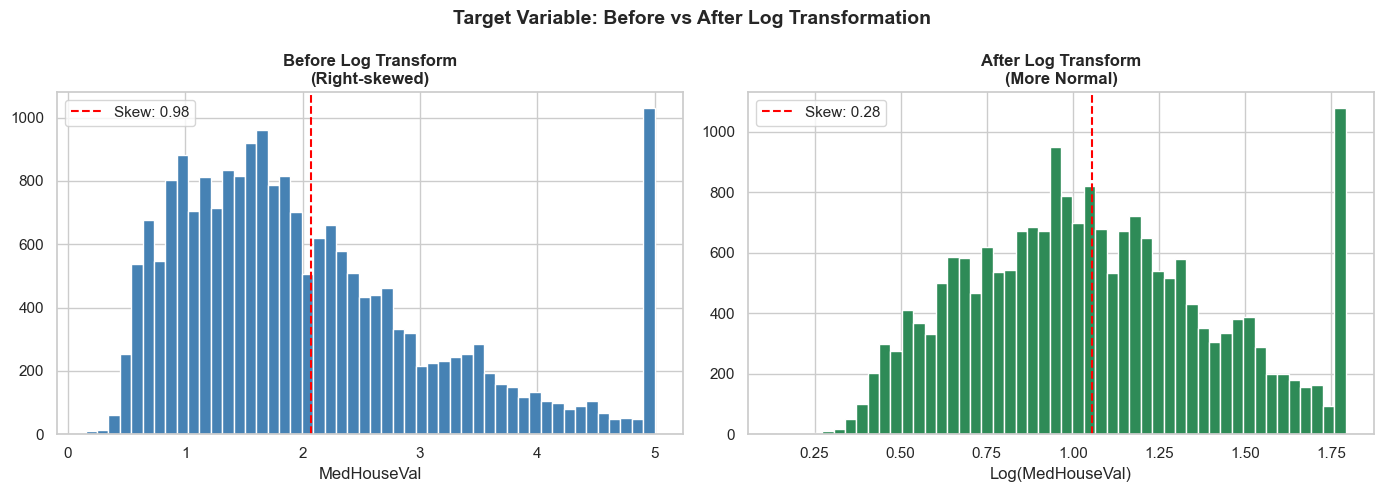

Skewness BEFORE: 0.9778
Skewness AFTER:  0.2759
✅ Skewness reduced significantly


In [4]:
# Cell 4: Log transformation of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before transformation
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Before Log Transform\n(Right-skewed)', fontweight='bold')
axes[0].set_xlabel('MedHouseVal')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--',
                label=f"Skew: {df['MedHouseVal'].skew():.2f}")
axes[0].legend()

# Apply log transformation
df['LogMedHouseVal'] = np.log1p(df['MedHouseVal'])
# np.log1p(x) = log(1+x) — safer than log(x) when values can be 0

# After transformation
axes[1].hist(df['LogMedHouseVal'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('After Log Transform\n(More Normal)', fontweight='bold')
axes[1].set_xlabel('Log(MedHouseVal)')
axes[1].axvline(df['LogMedHouseVal'].mean(), color='red', linestyle='--',
                label=f"Skew: {df['LogMedHouseVal'].skew():.2f}")
axes[1].legend()

plt.suptitle('Target Variable: Before vs After Log Transformation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/screenshots/log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness BEFORE: {df['MedHouseVal'].skew():.4f}")
print(f"Skewness AFTER:  {df['LogMedHouseVal'].skew():.4f}")
print("✅ Skewness reduced significantly")

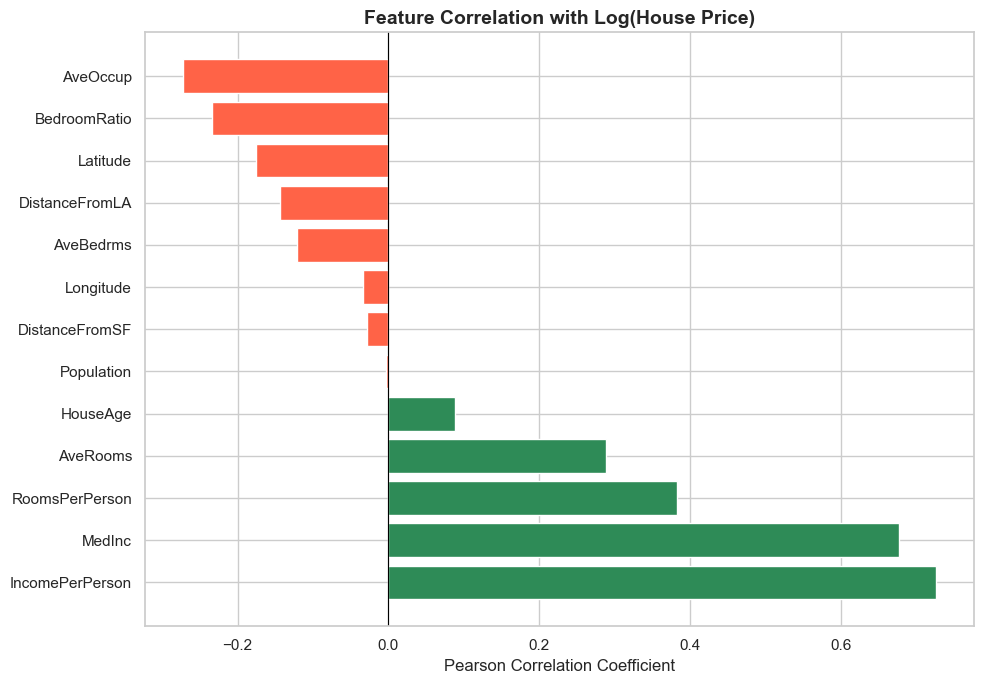


📌 Top 5 features by absolute correlation:
IncomePerPerson    0.726413
MedInc             0.676439
RoomsPerPerson     0.382957
AveRooms           0.288095
AveOccup           0.272408
Name: LogMedHouseVal, dtype: float64


In [5]:
# Cell 5: Check correlation of new features with target
corr_with_target = df.corr()['LogMedHouseVal'].drop(
    ['LogMedHouseVal', 'MedHouseVal']
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['seagreen' if x > 0 else 'tomato' for x in corr_with_target.values]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Log(House Price)',
          fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../assets/screenshots/feature_importance_corr.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Top 5 features by absolute correlation:")
print(corr_with_target.abs().sort_values(ascending=False).head(5))

In [6]:
# Cell 6: Define features (X) and target (y)

# Drop original target — we use the log version for training
# Drop MedHouseVal (original) to avoid leakage
# Keep LogMedHouseVal as our target

TARGET = 'LogMedHouseVal'

# All columns except both target versions
FEATURES = [col for col in df.columns
            if col not in ['MedHouseVal', 'LogMedHouseVal']]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"✅ Features (X): {len(FEATURES)} columns")
for f in FEATURES:
    print(f"   • {f}")
print(f"\n✅ Target (y): {TARGET}")
print(f"   Shape: X={X.shape}, y={y.shape}")

✅ Features (X): 13 columns
   • MedInc
   • HouseAge
   • AveRooms
   • AveBedrms
   • Population
   • AveOccup
   • Latitude
   • Longitude
   • RoomsPerPerson
   • BedroomRatio
   • IncomePerPerson
   • DistanceFromSF
   • DistanceFromLA

✅ Target (y): LogMedHouseVal
   Shape: X=(20640, 13), y=(20640,)


In [7]:
# Cell 7: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # fixed seed = reproducible results always
)

print("=" * 45)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 45)
print(f"  Total samples  : {len(X):,}")
print(f"  Training set   : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set       : {len(X_test):,}  rows ({len(X_test)/len(X)*100:.0f}%)")
print("=" * 45)
print("\n📌 WHY random_state=42?")
print("   Ensures anyone running this code gets identical splits.")
print("   Without it, results change every run — unprofessional.")

TRAIN / TEST SPLIT SUMMARY
  Total samples  : 20,640
  Training set   : 16,512 rows (80%)
  Test set       : 4,128  rows (20%)

📌 WHY random_state=42?
   Ensures anyone running this code gets identical splits.
   Without it, results change every run — unprofessional.


In [8]:
# Cell 8: Feature Scaling using StandardScaler
# StandardScaler: transforms each feature to mean=0, std=1

scaler = StandardScaler()

# CRITICAL RULE: fit ONLY on training data, then transform both
# Fitting on test data = data leakage = cheating
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only, no fit!

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURES)

print("✅ Scaling applied")
print("\nBEFORE scaling (X_train sample):")
display(X_train.describe().loc[['mean', 'std']].round(3))

print("\nAFTER scaling (X_train_scaled sample):")
display(X_train_scaled.describe().loc[['mean', 'std']].round(3))

print("\n📌 After scaling: mean ≈ 0, std ≈ 1 for all features ✅")

✅ Scaling applied

BEFORE scaling (X_train sample):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerPerson,BedroomRatio,IncomePerPerson,DistanceFromSF,DistanceFromLA
mean,3.881,28.608,5.313,1.059,1338.012,2.898,35.643,-119.582,1.933,0.211,1.416,3.865,2.657
std,1.904,12.602,1.246,0.081,764.977,0.691,2.137,2.006,0.602,0.056,0.755,2.499,2.419



AFTER scaling (X_train_scaled sample):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerPerson,BedroomRatio,IncomePerPerson,DistanceFromSF,DistanceFromLA
mean,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



📌 After scaling: mean ≈ 0, std ≈ 1 for all features ✅


In [9]:
# Cell 9: Save processed datasets to data/processed/
import os

save_path = '../data/processed/'
os.makedirs(save_path, exist_ok=True)

X_train_scaled.to_csv(f'{save_path}X_train.csv', index=False)
X_test_scaled.to_csv(f'{save_path}X_test.csv', index=False)
y_train.to_csv(f'{save_path}y_train.csv', index=False)
y_test.to_csv(f'{save_path}y_test.csv', index=False)

# Save feature names for later use in the app
import json
with open(f'{save_path}feature_names.json', 'w') as f:
    json.dump(FEATURES, f)

print("✅ Saved to data/processed/:")
for fname in os.listdir(save_path):
    size = os.path.getsize(f'{save_path}{fname}')
    print(f"   • {fname}  ({size:,} bytes)")

✅ Saved to data/processed/:
   • feature_names.json  (187 bytes)
   • housing_cleaned.csv │  (0 bytes)
   • X_test.csv  (1,056,750 bytes)
   • X_train.csv  (4,225,554 bytes)
   • y_test.csv  (81,950 bytes)
   • y_train.csv  (327,695 bytes)


In [10]:
# Cell 10: Summary
print("""
╔══════════════════════════════════════════════════════════╗
║           PREPROCESSING SUMMARY                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  ✅ Step 1: Outlier capping (IQR Winsorization)          ║
║             AveRooms, AveBedrms, AveOccup, Population   ║
║                                                          ║
║  ✅ Step 2: Feature Engineering (5 new features)         ║
║             RoomsPerPerson, BedroomRatio                 ║
║             IncomePerPerson                              ║
║             DistanceFromSF, DistanceFromLA               ║
║                                                          ║
║  ✅ Step 3: Log transform on target (MedHouseVal)        ║
║             Skewness reduced significantly               ║
║                                                          ║
║  ✅ Step 4: Train/Test Split (80% / 20%)                 ║
║             Training: 16,512 rows                        ║
║             Testing:   4,128 rows                        ║
║                                                          ║
║  ✅ Step 5: StandardScaler applied                       ║
║             Fitted on train only (no leakage)            ║
║                                                          ║
║  ✅ Step 6: Saved to data/processed/                     ║
║                                                          ║
║  📌 NEXT STEP: Phase 4 — Model Development               ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           PREPROCESSING SUMMARY                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  ✅ Step 1: Outlier capping (IQR Winsorization)          ║
║             AveRooms, AveBedrms, AveOccup, Population   ║
║                                                          ║
║  ✅ Step 2: Feature Engineering (5 new features)         ║
║             RoomsPerPerson, BedroomRatio                 ║
║             IncomePerPerson                              ║
║             DistanceFromSF, DistanceFromLA               ║
║                                                          ║
║  ✅ Step 3: Log transform on target (MedHouseVal)        ║
║             Skewness reduced significantly               ║
║                                                          ║
║  ✅ Step 4: Train/Test Split (80% / 20%)                 ║
║             Training: 16,5